In [1]:
#Codigo para abrir un txt y buscar la cadenasimilar a:
#"DEBUG - Driver loop - Current step: 86, Current episode: 0"

import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd

txt = open("salidaDB.txt", "r")
#Mostrar cantidad de lineas
lineas = txt.readlines()
print("Cantidad de lineas: ", len(lineas))
#Mostrar la primera linea
print("Primera linea: ", lineas[0])

C:\Users\cuent\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Cantidad de lineas:  51102
Primera linea:  Nooooooooooooooo - Rich library is not available ----------



In [ ]:
#Cada step tiene esta estrcutura:
#$$Frame Procs$$
#Plantilla detectada: i1F.png
#Pixels con 1's: Pasados al segundo canal
# - Cantidad (suma): 42
# - Ubicacion (lista de coords): [(60, 61), (60, 62), (60, 63), (60, 64), (60, 65), ...]
#Mejor similitud no detectada: None
#$$End$$

In [9]:
len(lineas)

51102

In [18]:
# Lista para guardar cada bloque de información
bloques = []
bloque_actual = []
# Indicamos si estamos dentro de un bloque
dentro_bloque = False

for linea in lineas:
    # Uso de regex para ser más flexible con espacios y formato
    if re.search(r'\$\$Frame Procs\$\$', linea):
        dentro_bloque = True
        bloque_actual = []  # Reinicia el bloque
    if dentro_bloque:
        bloque_actual.append(linea)
    # Uso de regex para detectar el final con mayor flexibilidad
    if re.search(r'\$\$End\$\$', linea) and dentro_bloque:
        bloques.append(bloque_actual)
        dentro_bloque = False

In [13]:
len(bloques)

7222

In [19]:
print(bloques[0])  # Muestra el primer bloque para verificar

['$$Frame Procs$$\n', 'Plantilla detectada: None\n', "Pixels con 1's: Pasados al segundo canal\n", ' - Cantidad (suma): 0\n', ' - Ubicacion (lista de coords): []\n', 'Mejor similitud no detectada: 0.0\n', '$$End$$\n']


In [20]:
# Lista para almacenar la información extraída de cada bloque
datos = []
for bloque in bloques:
    info = {}

    #Primera linea
    plantilla = bloque[1].split(":", 1)[1].strip()
    info["plantilla_detectada"] = plantilla

    # Segunda linea
    cantidad_str = bloque[3].split(":", 1)[1].strip()
    try:
        info["cantidad"] = int(cantidad_str)
    except ValueError:
        print(f"Error al convertir '{cantidad_str}' a int")
        info["cantidad"] = None
    
    #Tercera linea
    coords_str = bloque[4].split(":", 1)[1].strip()
    # Se capturan las coordenadas usando una expresión regular
    matches = re.findall(r"\((\d+),\s*(\d+)\)", coords_str)
    # Solo se toman las primeras 5 coordenadas
    ubicaciones = [f"({m[0]}, {m[1]})" for m in matches][:5]
    # Crear cinco columnas, asignando None si no hay suficiente información
    for i in range(5):
        key = f"ubicacion_{i+1}"
        info[key] = ubicaciones[i] if i < len(ubicaciones) else None

    datos.append(info)

# Creación del DataFrame
df = pd.DataFrame(datos)

In [21]:
df.shape

(7222, 7)

In [29]:
df.tail(50)

,plantilla_detectada,cantidad,ubicacion_1,ubicacion_2,ubicacion_3,ubicacion_4,ubicacion_5
7172,None,0,None,None,None,None,None
7173,None,0,None,None,None,None,None
7174,None,0,None,None,None,None,None
7175,i2F.png,49,"(60, 95)","(60, 96)","(60, 97)","(60, 98)","(60, 99)"
7176,None,0,None,None,None,None,None
7177,None,0,None,None,None,None,None
7178,None,0,None,None,None,None,None
7179,None,0,None,None,None,None,None
7180,None,0,None,None,None,None,None
7181,None,0,None,None,None,None,None


In [27]:
df.ubicacion_1.isnull().sum()/df.shape[0] * 100

36.92882857934091

In [30]:
df.ubicacion_1.value_counts()

ubicacion_1
(60, 61)    956
(60, 60)    663
(60, 62)    368
(60, 65)     47
(60, 57)     40
           ... 
(71, 50)      1
(29, 10)      1
(41, 78)      1
(36, 10)      1
(72, 96)      1
Name: count, Length: 568, dtype: int64

In [ ]:
#Buscar la cadena en el txt, las x pueden ser cualquier numero
busqueda = "DEBUG - Driver loop - Current step: x , Current episode: x"
#Expresion regular para buscar la cadena, modificar para que sea un poco mas flexible
expresion = r".*DEBUG.*Driver loop.*Current step:?\s*\d+\s*,\s*Current episode:?\s*\d+.*"

#Extrare la cadena de cada linea y guardarla en una lista
lista = []
for linea in lineas:
    #Buscar la cadena en la linea
    if re.search(expresion, linea):
        #Si la cadena se encuentra, agregarla a la lista
        lista.append(linea)

print(len(lista))


26142


In [5]:
#Mostrar la primera linea
print("Primera linea: ", lista[0])

Primera linea:  DEBUG - Driver loop - Current step: 0, Current episode: 0



In [10]:
#Crear un dataframe para guardar los episodios y pasos por episodio
df = pd.DataFrame(columns=["Episodio", "Pasos"])
#Recorrer la lista y extraer los episodios y pasos por episodio
episodios_list = []
pasos_list = []

for linea in lista:
    #Buscar la cadena en la linea
    match = re.search(r".*Current step:?\s*(\d+).*Current episode:?\s*(\d+)", linea)
    if match:
        #Si la cadena se encuentra, agregarla a la lista
        pasos = int(match.group(1))
        episodio = int(match.group(2))
        episodios_list.append(episodio)
        pasos_list.append(pasos)

df["Episodio"] = episodios_list
df["Pasos"] = pasos_list

In [14]:
df.head(200)

,Episodio,Pasos
0,0,0
1,0,1
2,0,2
3,0,3
4,0,4
...,...,...
195,0,95
196,0,96
197,0,97
198,0,98


In [21]:
breakpoint = 0

for row in df.iterrows():
    print("episodio",row[1]["Episodio"], "Paso",row[1]["Pasos"])

    if breakpoint == 500:
        break

    breakpoint += 1

episodio 0 Paso 0
episodio 0 Paso 1
episodio 0 Paso 2
episodio 0 Paso 3
episodio 0 Paso 4
episodio 0 Paso 5
episodio 0 Paso 6
episodio 0 Paso 7
episodio 0 Paso 8
episodio 0 Paso 9
episodio 0 Paso 10
episodio 0 Paso 11
episodio 0 Paso 12
episodio 0 Paso 13
episodio 0 Paso 14
episodio 0 Paso 15
episodio 0 Paso 16
episodio 0 Paso 17
episodio 0 Paso 18
episodio 0 Paso 19
episodio 0 Paso 20
episodio 0 Paso 21
episodio 0 Paso 22
episodio 0 Paso 23
episodio 0 Paso 24
episodio 0 Paso 25
episodio 0 Paso 26
episodio 0 Paso 27
episodio 0 Paso 28
episodio 0 Paso 29
episodio 0 Paso 30
episodio 0 Paso 31
episodio 0 Paso 32
episodio 0 Paso 33
episodio 0 Paso 34
episodio 0 Paso 35
episodio 0 Paso 36
episodio 0 Paso 37
episodio 0 Paso 38
episodio 0 Paso 39
episodio 0 Paso 40
episodio 0 Paso 41
episodio 0 Paso 42
episodio 0 Paso 43
episodio 0 Paso 44
episodio 0 Paso 45
episodio 0 Paso 46
episodio 0 Paso 47
episodio 0 Paso 48
episodio 0 Paso 49
episodio 0 Paso 50
episodio 0 Paso 51
episodio 0 Paso 52
epi

In [18]:
last_ep = -1

for row in df.iterrows():
    if last_ep != row[1]["Episodio"]:
        print("episodio",row[1]["Episodio"], "Paso",row[1]["Pasos"])
        last_ep = row[1]["Episodio"]

episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Paso 0
episodio 1 Paso 100
episodio 2 Paso 200
episodio 0 Pas

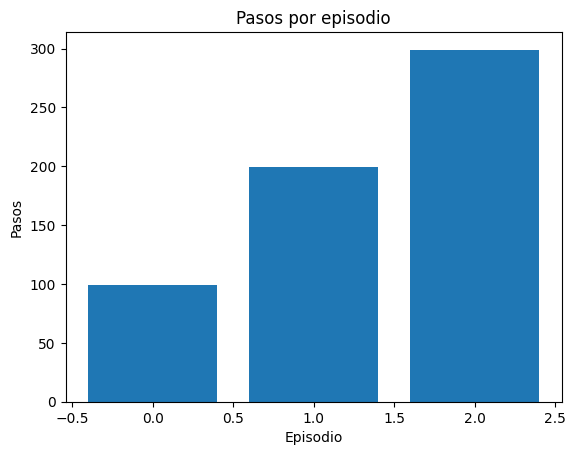

In [12]:
#Mostrar el grafico de barras
plt.bar(df["Episodio"], df["Pasos"])
plt.xlabel("Episodio")
plt.ylabel("Pasos")
plt.title("Pasos por episodio")
plt.show()

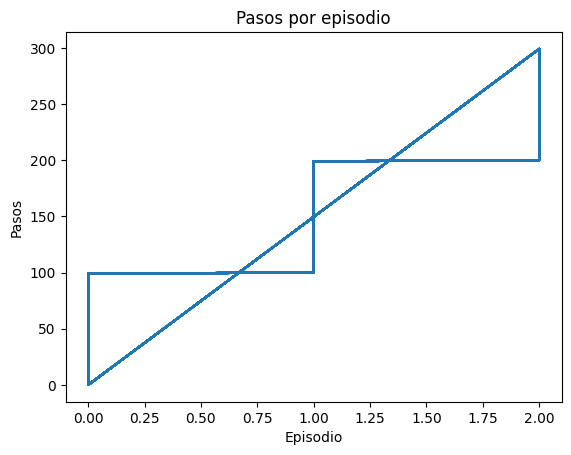

In [13]:
#Haz una grafica de lineas, una por episodio y ve mostrando los pasos por episodio
plt.plot(df["Episodio"], df["Pasos"])
plt.xlabel("Episodio")
plt.ylabel("Pasos")
plt.title("Pasos por episodio")
plt.show()